# How does SVM work, and why are they different from logistic? Write your answer in text.

SVM, Support Vector Machine, is a type of model that is mainly used for classification and can be used for binary of multiclass data, it works by placing a line (hyperplane) that seperates the data points into their classes and so if a point is on a side of it it is classified as that. The difference between it and logistic regression is that logistic regression is fundementally a probabilistic model that works by transforming the input features into a probability and that number decides which class an input belongs to, while SVM works by placing a line or a boundry that seperates the data and what side that data point is on decides the class it is, it is implemented in two ways a boundry with a hard margin which means there is a margin that all points must be outside so the line can be general enough for use, and there is another with a soft margin which points placed inside the margin are used to penalise the line the model gave but it allows for less extreme (general) boundries. Another point is that svm are heavily dependant on points that are called support vectors and these are the points closest to it while the points that are farther away barely have weight in chaning that boundry.

A special thing about svm's is the ability to use what is called a kernalised svm which the kernal is used before trying to place the boundry elevates the dimension of the data to a higher dimension allwoing the data to be seperable if it was not in the original dimension and so new inputs can also be transformed and decided on which side they go on in the higher dimension. The special thing about this higher dimension transformation is that it can be done very quickly in most cases because it is not actually turning an input of (x,y) into (x,y,z) where z is a function of x and y but it can be done using a simpler less expensive function that is the inner product of the x and y where they are in put through a simple function, allowing for an answer to be given even when it looks impossible to be done.

## Hard-Margin and Soft-Margin Experiments

I reused the IMDB sentiment dataset and the preprocessing, tokenization, and TF-IDF vectorizer from the previous logistic-regression work. The split is 60% training, 20% validation, and 20% testing. The vectorizer is fitted only on the training reviews so that vocabulary and IDF information cannot leak from validation or test data.

**Assumption about the plan:** an exact hard-margin SVM requires perfectly linearly separable data. Real IMDB reviews contain noise and overlapping language, so a true hard-margin solution may not exist. I use a linear SVM with a very large `C` (`1,000,000`) as the usual practical approximation and report its remaining margin violations instead of claiming it is a mathematically exact hard-margin solution. The soft-margin experiment uses finite `C` values selected with the validation set.

In [1]:
from pathlib import Path
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# Locate the repository no matter whether the notebook is opened from its own folder
# or from the repository root.
current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "phase-1-machine-learning-nlp").is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

phase_1 = repository_root / "phase-1-machine-learning-nlp"
part_02 = phase_1 / "02-preprocessing-tokenization"
part_06 = phase_1 / "06-vectorization"
sys.path.insert(0, str(part_02 / "src"))
sys.path.insert(0, str(part_06 / "src"))

from preprocessor import preprocess_text
from tokenizer import regex_tokenize
from vectorizer import CustomTfidfVectorizer

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

imdb = pd.read_csv(imdb_path)
required_columns = {"review", "sentiment"}
if not required_columns.issubset(imdb.columns):
    raise KeyError(f"The IMDB dataset must contain {sorted(required_columns)}.")

imdb = imdb.dropna(subset=["review", "sentiment"])
imdb = imdb.drop_duplicates(subset="review").reset_index(drop=True)
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
if imdb["label"].isna().any():
    raise ValueError("Sentiment labels must be either 'negative' or 'positive'.")

X_development, X_test, y_development, y_test = train_test_split(
    imdb["review"],
    imdb["label"],
    test_size=0.20,
    random_state=42,
    stratify=imdb["label"],
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    random_state=42,
    stratify=y_development,
)

split_summary = pd.DataFrame(
    {
        "reviews": [len(X_train), len(X_validation), len(X_test)],
        "positive proportion": [
            y_train.mean(), y_validation.mean(), y_test.mean()
        ],
    },
    index=["train", "validation", "test"],
)
display(split_summary.style.format({"positive proportion": "{:.4f}"}))


,reviews,positive proportion
train,29748,0.5019
validation,9917,0.5019
test,9917,0.5019


In [2]:
# Reuse the custom TF-IDF implementation from Topic 6.
vectorizer = CustomTfidfVectorizer(
    preprocessor=preprocess_text,
    tokenizer=regex_tokenize,
    min_df=5,
    max_df=0.95,
    max_features=30_000,
)

vectorization_start = time.perf_counter()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_validation_tfidf = vectorizer.transform(X_validation)
X_test_tfidf = vectorizer.transform(X_test)
vectorization_seconds = time.perf_counter() - vectorization_start

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Vectorization time: {vectorization_seconds:.2f} seconds")


Vocabulary size: 30,000
Training matrix shape: (29748, 30000)
Vectorization time: 28.99 seconds


### Hard-margin approximation

For a linear SVM, increasing `C` makes violations extremely expensive. I therefore use `C=1,000,000` with hinge loss. I report both classification metrics and how many training examples remain inside the margin or on the wrong side of the boundary.

In [3]:
def classification_metrics(labels, predictions):
    return pd.Series({
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "F1": f1_score(labels, predictions, zero_division=0),
    })


hard_margin_model = LinearSVC(
    C=1_000_000.0,
    loss="hinge",
    dual=True,
    tol=1e-4,
    max_iter=20_000,
    random_state=42,
)

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always", ConvergenceWarning)
    hard_start = time.perf_counter()
    hard_margin_model.fit(X_train_tfidf, y_train)
    hard_training_seconds = time.perf_counter() - hard_start

hard_train_predictions = hard_margin_model.predict(X_train_tfidf)
hard_test_predictions = hard_margin_model.predict(X_test_tfidf)

# For labels encoded as 0/1, change them to -1/+1 before calculating y*f(x).
signed_train_labels = np.where(y_train.to_numpy() == 1, 1.0, -1.0)
signed_distances = signed_train_labels * hard_margin_model.decision_function(
    X_train_tfidf
)
hard_margin_violations = int(np.sum(signed_distances < 1.0 - 1e-6))
hard_misclassifications = int(np.sum(signed_distances <= 0.0))

hard_margin_results = pd.concat(
    {
        "train": classification_metrics(y_train, hard_train_predictions),
        "test": classification_metrics(y_test, hard_test_predictions),
    },
    axis=1,
).T

display(hard_margin_results.style.format("{:.4f}"))
print(f"Training time: {hard_training_seconds:.2f} seconds")
print(f"Training points with y*f(x) < 1: {hard_margin_violations:,}")
print(f"Training misclassifications: {hard_misclassifications:,}")
print(f"Solver iterations: {hard_margin_model.n_iter_:,}")
print(
    "Convergence warning raised:",
    any(issubclass(item.category, ConvergenceWarning) for item in caught_warnings),
)


,accuracy,precision,recall,F1
train,1.0000,1.0000,1.0000,1.0000
test,0.8597,0.8565,0.8656,0.8610


Training time: 259.39 seconds
Training points with y*f(x) < 1: 206
Training misclassifications: 0
Solver iterations: 20,000
Convergence warning raised: True


### Soft-margin SVM with validation tuning

I tune `C` over `[0.01, 0.1, 1, 10]`. A smaller `C` accepts more margin violations for stronger regularization; a larger `C` penalizes violations more. Validation F1 chooses the winner. The test set is used only once after that choice.

In [4]:
soft_margin_rows = []
soft_margin_models = []

for C in [0.01, 0.1, 1.0, 10.0]:
    candidate = LinearSVC(
        C=C,
        loss="squared_hinge",
        dual="auto",
        tol=1e-4,
        max_iter=10_000,
        random_state=42,
    )
    start = time.perf_counter()
    candidate.fit(X_train_tfidf, y_train)
    training_seconds = time.perf_counter() - start
    validation_predictions = candidate.predict(X_validation_tfidf)

    metrics = classification_metrics(y_validation, validation_predictions)
    soft_margin_rows.append({
        "C": C,
        "validation accuracy": metrics["accuracy"],
        "validation precision": metrics["precision"],
        "validation recall": metrics["recall"],
        "validation F1": metrics["F1"],
        "training seconds": training_seconds,
        "iterations": candidate.n_iter_,
    })
    soft_margin_models.append(candidate)

soft_margin_search = pd.DataFrame(soft_margin_rows)
best_index = int(soft_margin_search["validation F1"].idxmax())
best_soft_margin_model = soft_margin_models[best_index]
best_C = float(soft_margin_search.loc[best_index, "C"])

display(soft_margin_search.style.format({
    "C": "{:.2g}",
    "validation accuracy": "{:.4f}",
    "validation precision": "{:.4f}",
    "validation recall": "{:.4f}",
    "validation F1": "{:.4f}",
    "training seconds": "{:.2f}",
}))
print(f"Selected C using validation F1: {best_C:g}")


,C,validation accuracy,validation precision,validation recall,validation F1,training seconds,iterations
0,0.01,0.8380,0.8075,0.8891,0.8463,0.34,7
1,0.1,0.8649,0.8510,0.8859,0.8681,0.47,12
2,1,0.8928,0.8840,0.9052,0.8945,1.51,34
3,10,0.8931,0.8891,0.8991,0.8941,5.68,214


Selected C using validation F1: 1


,accuracy,precision,recall,F1
hard-margin approximation,0.8597,0.8565,0.8656,0.8610
soft margin (C=1),0.8921,0.8842,0.9034,0.8937


Soft-margin test classification report:
              precision    recall  f1-score   support

    negative     0.9005    0.8808    0.8905      4940
    positive     0.8842    0.9034    0.8937      4977

    accuracy                         0.8921      9917
   macro avg     0.8923    0.8921    0.8921      9917
weighted avg     0.8923    0.8921    0.8921      9917



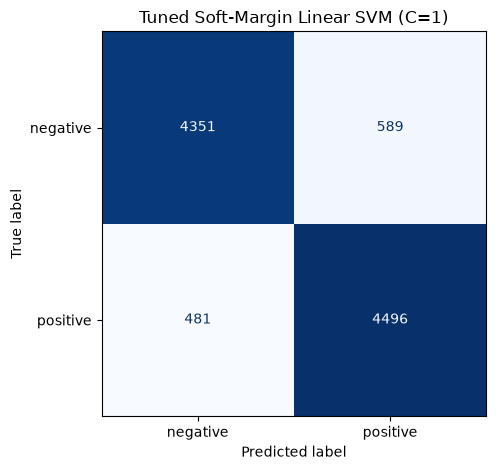

In [5]:
soft_test_predictions = best_soft_margin_model.predict(X_test_tfidf)
soft_test_metrics = classification_metrics(y_test, soft_test_predictions)

comparison = pd.DataFrame({
    "hard-margin approximation": classification_metrics(
        y_test, hard_test_predictions
    ),
    f"soft margin (C={best_C:g})": soft_test_metrics,
}).T

display(comparison.style.format("{:.4f}"))
print("Soft-margin test classification report:")
print(classification_report(
    y_test,
    soft_test_predictions,
    target_names=["negative", "positive"],
    digits=4,
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    soft_test_predictions,
    display_labels=["negative", "positive"],
    cmap="Blues",
    colorbar=False,
)
plt.title(f"Tuned Soft-Margin Linear SVM (C={best_C:g})")
plt.tight_layout()
plt.show()


### Observations

- The very-large-`C` model fitted the training labels perfectly, but its test F1 was only `0.8610`. It also reached the `20,000`-iteration limit and left `206` training points inside the margin. This supports the assumption that the noisy IMDB features are not cleanly separable and that forcing an almost-hard margin is numerically difficult.
- Validation F1 selected `C=1`. Its test accuracy was `0.8921` and its test F1 was `0.8937`, about `0.0327` higher than the hard-margin approximation.
- The soft-margin result generalised better because it allowed some violations instead of trying to fit every training review exactly. `C=10` had nearly the same validation accuracy, but slightly lower validation F1 and much longer training time, so the extra penalty was not useful here.
- The selected model had positive-class precision `0.8842` and recall `0.9034`. It found most positive reviews, but the lower precision means some negative reviews were predicted as positive.